This notebook concentrates on algorithmic audio processing; see also ./tf.ipynb

# imports

In [1]:
# verify version
import sys
assert sys.version.split('.')[0] == '3'
!which python

/Users/andreassteiner/git/rizhom/env/bin/python


In [2]:
from matplotlib import pyplot as plt
import numpy as np
import numpy
import scipy.io.wavfile
import scipy.signal

import pyaudio
import aubio
# import bob.ap

In [3]:
%load_ext autoreload
%autoreload 2

In [530]:
import os.path, sys

lib_path = '../py'
assert os.path.exists(lib_path), 'Make sure "." path is where notebooks are!'
if not lib_path in sys.path:
    sys.path.insert(0, lib_path)

import abase, audio, features, hotplug, settings, signals as S, streaming, util

hp = hotplug.HotPlug()

2019-04-22 17:04:36,838 - INFO - Reloaded ../py/hotplug_signals.py
2019-04-22 17:04:36,838 - INFO - Reloaded ../py/hotplug_signals.py
2019-04-22 17:04:36,838 - INFO - Reloaded ../py/hotplug_signals.py
2019-04-22 17:04:36,838 - INFO - Reloaded ../py/hotplug_signals.py


In [5]:
# Using interface `0` by default.
p = pyaudio.PyAudio()
for i in range(p.get_device_count()):#list all available audio devices
    dev = p.get_device_info_by_index(i)
    print((i, dev['name'], dev['maxInputChannels']))

(0, 'Built-in Microphone', 2)
(1, 'Built-in Output', 0)
(2, 'iShowU Audio Capture', 2)
(3, 'Multi-Output Device', 0)


# record

In [8]:
settings.to_string()

'rate=16000 buf_secs=0.064s (1024) hop_secs=0.032s (512) '

* recording
* done recording


(111616, 6.976)

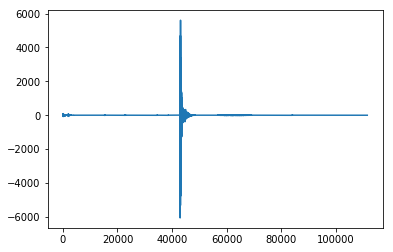

In [11]:
# record ...
data = audio.record(secs=7)
plt.plot(data)
len(data), len(data)/settings.rate

In [94]:
# store recording...
scipy.io.wavfile.write('../recordings/t_a_5.wav', rate, data)
# !ls -lh ../recordings/*

-rw-rw-r-- 1 gabriel gabriel 219K Apr 10 21:46 ../recordings/a_welle.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:11 ../recordings/m_g_1.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:11 ../recordings/m_g_2.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:11 ../recordings/m_g_3.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:12 ../recordings/m_g_4.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:12 ../recordings/m_g_5.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:13 ../recordings/o_a_1.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:13 ../recordings/o_a_2.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:13 ../recordings/o_a_3.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:13 ../recordings/o_a_4.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:14 ../recordings/o_a_5.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 10 23:56 ../recordings/o_g_1.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 10 23:57 ../recordings/o_g_2.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 10 23:57 ../recordings/o_g_3.wav
-rw-

In [7]:
ab = abase.ABase(load_wav=True)
ab

ABase(n=35, series=8, what=o:15|t:14|m:5|w:1, who=g:15|a:11|p:9)

In [12]:
ab.play('o_g_1', stop=2)

# abase, transform

In [429]:
ab = abase.ABase(load_wav=True)
ab.load('logmel')
ab.load('mfccs')

loaded 35/35 (100.00%)
loaded 35/35 (100.00%)


Updated 35/35 (100.0%)
/Users/andreassteiner/git/rizhom/.abase_cache/logmel.pickle : 3.71M (0.0s)


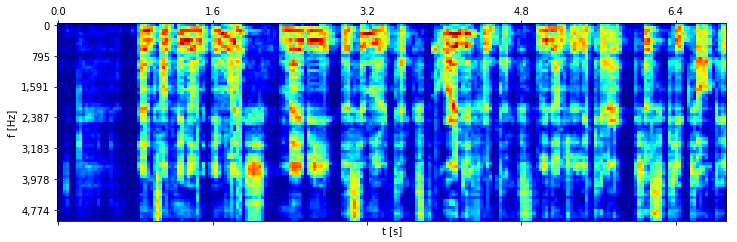

In [361]:
ab.transform('logmel', lambda row: features.log_mel_spectrogram(row['wav']))
util.plot_logmel(ab.df.loc[ab.sample(), 'logmel'])

loaded 35/35 (100.00%)
Updated 35/35 (100.0%)
/Users/andreassteiner/git/rizhom/.abase_cache/mfccs.pickle : 0.70M (0.0s)


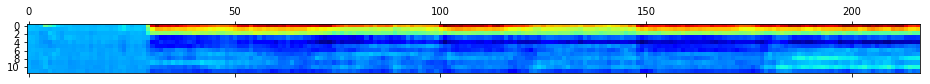

In [362]:
ab.load('logmel')
ab.transform('mfccs', lambda row: features.mfccs(data=None, logmel=row['logmel']))
plt.matshow(ab.df.loc[ab.sample(), 'mfccs'].T, cmap='jet')

# analyze

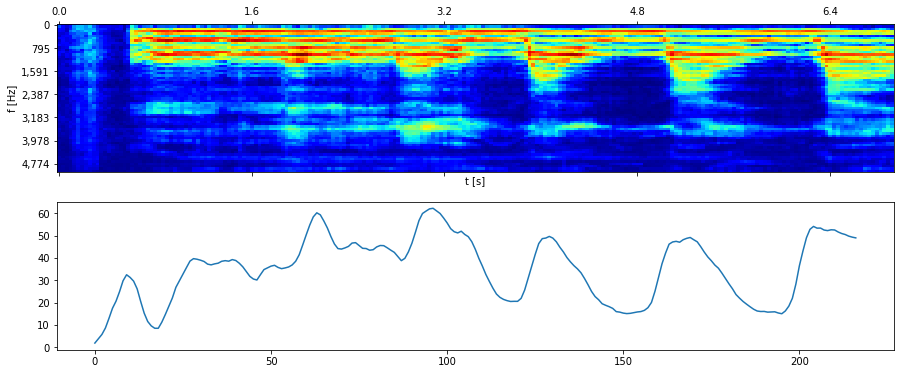

In [339]:
name = 'o_p_4'
name = 'o_g_3'
logmel = ab.df.loc[name, 'logmel']
plt.figure(figsize=(15, 6))
util.plot_logmel(logmel, ax=plt.subplot(211), aspect='auto')
weighted = (np.array([range(logmel.shape[1])]) * (logmel - logmel.min())).mean(axis=1)
ma = streaming.MovingAverage(5)
plt.subplot(212).plot([ma(_) for _ in weighted]);

In [341]:
ab.play(name)

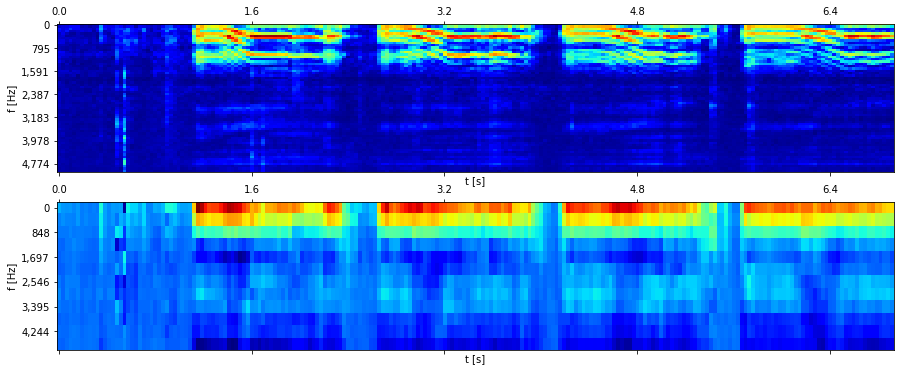

In [315]:
plt.figure(figsize=(15, 6))
util.plot_logmel(ab.df.loc['o_p_4', 'logmel'], ax=plt.subplot(211), aspect='auto')
util.plot_logmel(ab.df.loc['o_p_4', 'mfccs'], ax=plt.subplot(212), aspect='auto')

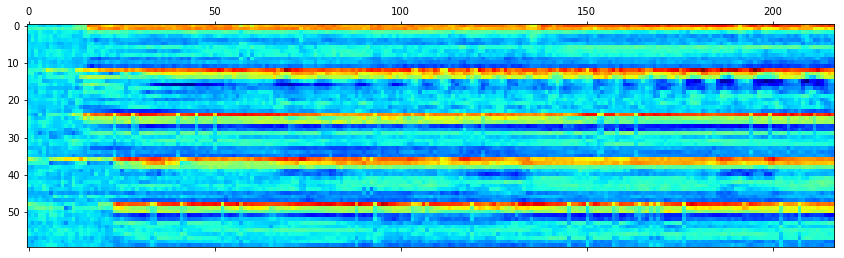

In [292]:
plt.matshow(np.hstack(ab.df.loc[ab.query('what == "o"').sample(5)].mfccs.values).T, cmap='jet')

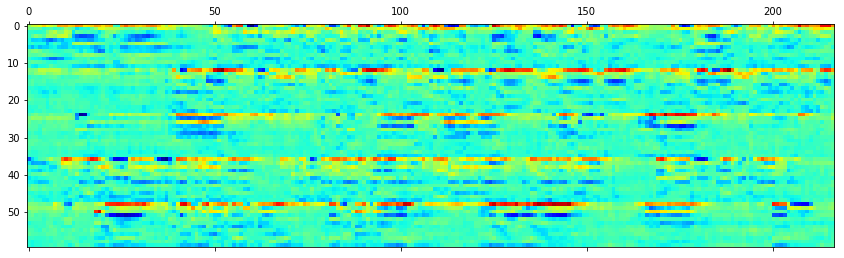

In [293]:
plt.matshow(np.hstack(ab.df.loc[ab.query('what == "t"').sample(5)].mfccs.values).T, cmap='jet')

## signals

incubating ... to be moved to "signal" module

## plot

In [511]:
def plot_signals(row, signals1, signals2=(), cols='krgbmcy'):
    """Displays logmel and values derived from signals1,2 on twin axes."""
    plt.figure(figsize=(15, 6))
    util.plot_logmel(row.logmel, ax=plt.subplot(211), aspect='auto')
    i = 0
    signals = list(signals1) + list(signals2)
    values = [[] for _ in signals]
    for buf in streaming.Streamer(row.wav):
        feats = features.wav2features(buf)
        for i, signal in enumerate(signals):
            values[i].append(signal(feats))
    axs = [plt.subplot(212), plt.subplot(212).twinx()]
    for i, signal in enumerate(signals):
        axs[i >= len(signals1)].plot(
            values[i], cols[i % len(cols)] + ('-' if i < len(signals1) else '--'))
    return values

In [539]:
list('abcd'), '- -- : ;'.split(' ')

(['a', 'b', 'c', 'd'], ['-', '--', ':', ';'])

/Users/andreassteiner/git/rizhom/env/lib/python3.7/site-packages/matplotlib/figure.py:98: MatplotlibDeprecationWarning: 
Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  "Adding an axes using the same arguments as a previous axes "


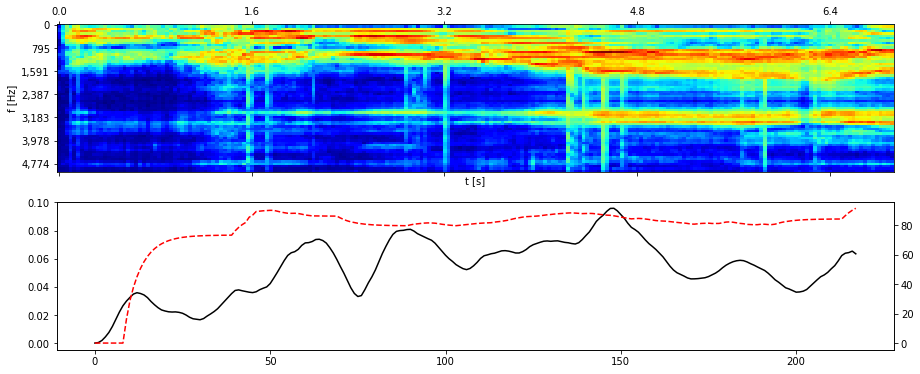

In [512]:
vs = plot_signals(ab.data.o_a_3, [
    # 0..1 axis
    S.Louder() | S.F(mult=10),
#     ThresholdedFrequencies(hz=2000, threshold=-1, bins=3)
], [
    # freq axis
    S.Pitcher() | S.Limiter(maxv=300) | S.Expontential(alpha=0.8),
#     WeightedAverage(),
])

In [506]:
ab.data.o_a_3.play()

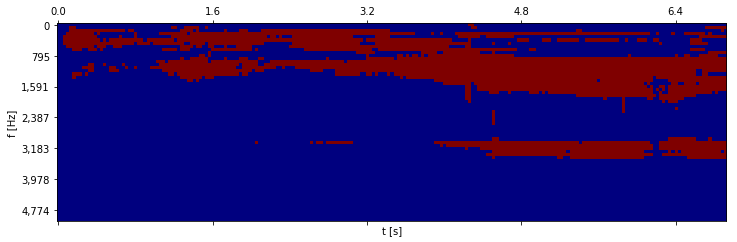

In [467]:
util.plot_logmel(ab.data.o_a_3.logmel > -1)

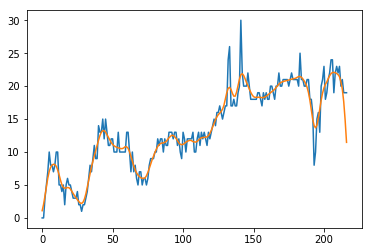

In [462]:
x = (ab.data.o_a_3.logmel > -1).sum(axis=1)
plt.plot(x)
w = np.hamming(11)
plt.plot(numpy.convolve(x, w, mode='same')/w.sum())

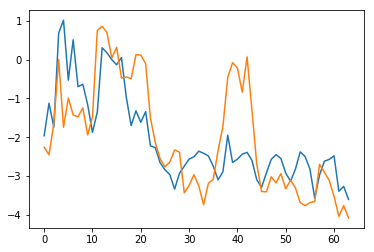

In [443]:
plt.plot(ab.data.o_a_3.logmel[int(1.6/settings.hop_secs), :])
plt.plot(ab.data.o_a_3.logmel[int(4.8/settings.hop_secs), :])

In [431]:
ab.data.o_a_3.play()

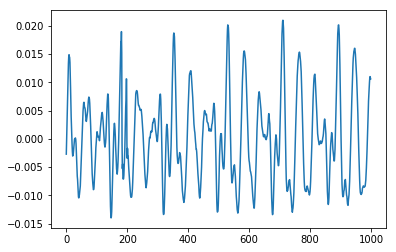

In [434]:
w = ab.data.o_a_3.wav
t0 = int(settings.rate*1.6)
plt.plot(w[t0:t0+1000])

Updated 35/35 (100.0%)
/Users/andreassteiner/git/rizhom/.abase_cache/loud.pickle : 0.06M (0.0s)
Updated 35/35 (100.0%)
/Users/andreassteiner/git/rizhom/.abase_cache/pitch.pickle : 0.03M (0.0s)
o => b
t => g
m => r


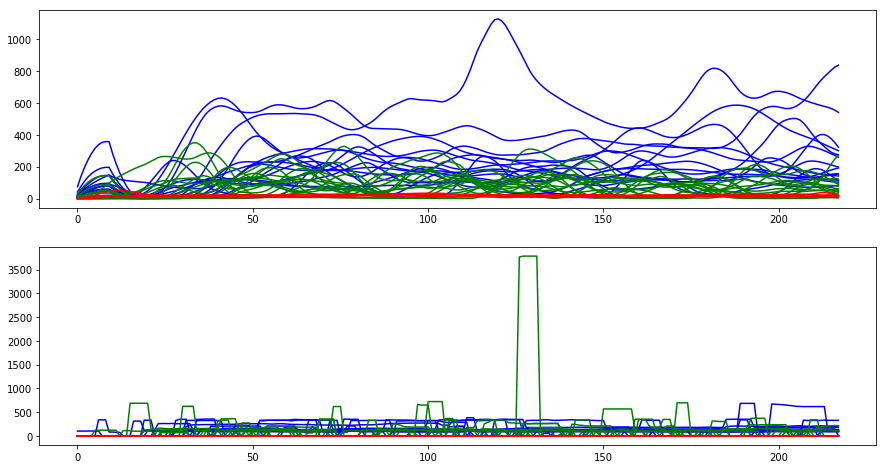

In [116]:

def plot_loud_pitch(ab, whats, tolerance=0.8, sample=0):

    def make_loud(row):
        louder = Louder()
        return np.array([
            louder(envelop_averager(buf))
            for buf in streaming.Streamer(row['wav'])
        ])

    def make_pitch(row):
        pitcher = Pitcher(tolerance=tolerance)
        return np.array([
            pitcher(buf)
            for buf in streaming.Streamer(row['wav'])
        ])

    ab.clear('loud')
    ab.transform('loud', make_loud)

    ab.clear('pitch')
    ab.transform('pitch', make_pitch)

    cols = ('b', 'g', 'r', 'k')
    _, axs = plt.subplots(2, 1, figsize=(15, 8))
    for i, what in enumerate(whats):
        col = cols[i % len(cols)]
        print('{} => {}'.format(what, col))
        df = ab.df.query('what == "{}"'.format(what))
        if sample:
            df = df.sample(n=sample)
            
        axs[0].plot(np.array(list(df.loud)).T, col)
        axs[1].plot(np.array(list(df.pitch)).T, col)

plot_loud_pitch(ab, whats=('o', 't', 'm'))

Updated 35/35 (100.0%)
/Users/andreassteiner/git/rizhom/.abase_cache/loud.pickle : 0.06M (0.0s)
Updated 35/35 (100.0%)
/Users/andreassteiner/git/rizhom/.abase_cache/pitch.pickle : 0.03M (0.0s)
o => b
t => g
m => r


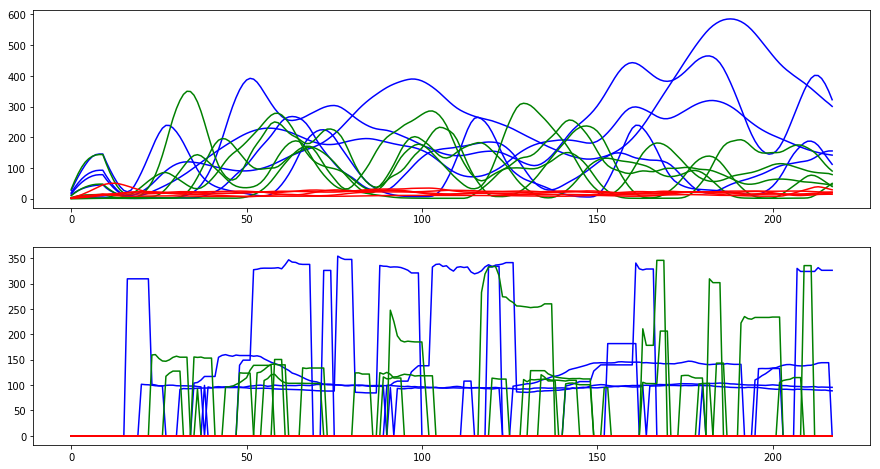

In [121]:
plot_loud_pitch(ab, whats=('o', 't', 'm'), tolerance=0.3, sample=5)

# effects

'o_p_3'

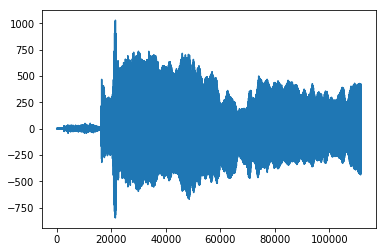

In [132]:
name = ab.sample()
wav = ab.df.loc[name].wav
plt.plot(wav)
name

## echo

In [273]:
class EchoDelayEffect:
    def __init__(self, delay_s=0.2, coeff=0.7):
        """Use coeff=0 for pure delay."""
        self.delay_s = delay_s
        self.delay_n = int(delay_s / settings.hop_secs)
        self.coeff = coeff
        self.bufs = np.zeros((self.delay_n, settings.hop_size))
        self.i = 0

    def __call__(self, buf):
        assert buf.dtype == np.float32
        assert len(buf) == settings.buf_size
        buf = buf[:settings.hop_size]
        n = self.bufs.shape[0]
        delayed = self.bufs[self.i % n].copy()
        if self.coeff > 0:
            self.bufs[self.i % n] = buf + delayed * self.coeff
            ret = self.bufs[self.i % n]
        else:
            self.bufs[self.i % n] = buf
            ret = delayed
        self.i += 1
        return ret


# does NOT work (clicking)
class LowpassEffect:
    def __init__(self, cutoff=880, numtaps=40):
        self.h = scipy.signal.firwin(numtaps=numtaps, cutoff=cutoff,
                                     nyq=settings.rate/2)

    def __call__(self, buf):
        assert buf.dtype == np.float32
        assert len(buf) == settings.buf_size
        buf = scipy.signal.lfilter(self.h, 1.0, buf)
        d = int((settings.buf_size - settings.hop_size)/2)
        return buf[d: settings.hop_size]

audio_interface = audio.AudioInterface(output_channels = 1)
effect = EchoDelayEffect()
# effect = EchoDelayEffect(delay_s=2, coeff=0)
# effect = LowpassEffect()
secs = 0
wav = ab.df.loc['o_p_2', 'wav']
for i, data in enumerate(streaming.Streamer(wav)):
    if secs and i > secs / settings.hop_secs:
        break
    data = util.int16_to_float(data)
    data = effect(data)
    data = util.float_to_int16(data)
    audio_interface.play(data)

## stereo

In [276]:
class PanSinusEffect:
    def __init__(self, period_s=4):
        self.period_s = period_s
        self.i = 0

    def __call__(self, buf):
        assert buf.dtype == np.float32
        assert len(buf) == settings.buf_size
        buf = buf[: settings.hop_size]
        v = (1 + np.sin(self.i * settings.hop_secs / self.period_s * 2 * np.pi)) / 2
        self.i += 1
        left = buf * v
        right = buf * (1 - v)
        return np.vstack([left, right]).reshape(-1, order='F')

class RightDelayEffect:
    def __init__(self, delay_s=2):
        self.delay_s = delay_s
        self.delay_effect = EchoDelayEffect(delay_s=delay_s, coeff=0)

    def __call__(self, buf):
        assert buf.dtype == np.float32
        assert len(buf) == settings.buf_size
        left = buf[: settings.hop_size]
        right = self.delay_effect(buf)
        return np.vstack([left, right]).reshape(-1, order='F')

class MonoToStereoEffect:
    def __call__(self, buf):
        assert buf.dtype == np.float32
        assert len(buf) == settings.buf_size
        buf = buf[: settings.hop_size]
        return np.vstack([buf, buf]).reshape(-1, order='F')

audio_interface = audio.AudioInterface(input=False, output=True, output_channels=2)
effect = PanSinusEffect()
effect = RightDelayEffect()
secs = 0
wav = ab.df.loc['t_g_1', 'wav']
for i, data in enumerate(streaming.Streamer(wav)):
    if secs and i > secs / settings.hop_secs:
        break
    data = util.int16_to_float(data)
    data = effect(data)
    data = util.float_to_int16(data)
    audio_interface.play(data)

## compose

In [275]:
audio_interface = audio.AudioInterface(output_channels=2)
# effect = PanSinusEffect()
effect = RightDelayEffect()
secs = 0
wav = ab.df.loc['o_p_5', 'wav']
for i, data in enumerate(streaming.Streamer(wav)):
    if secs and i > secs / settings.hop_secs:
        break
    data = util.int16_to_float(data)
    data = effect(data)
    data = util.float_to_int16(data)
    audio_interface.play(data)

## frequency filters

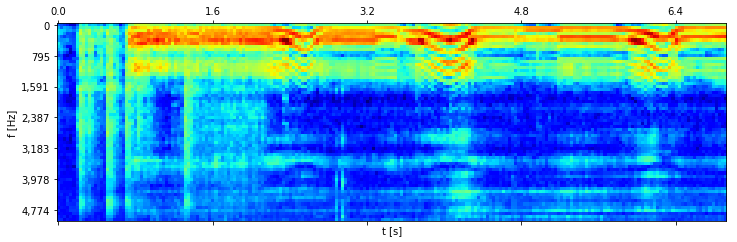

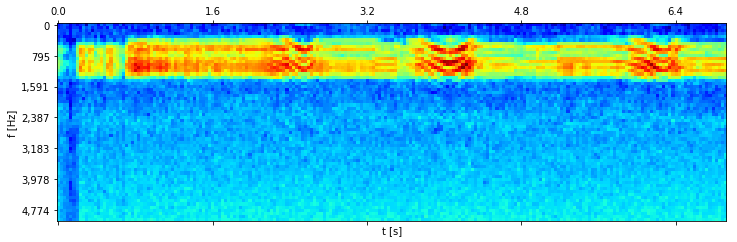

In [197]:
def butter_highpass(cutoff, order=5):
    nyq = 0.5 * settings.rate
    normal_cutoff = cutoff / nyq
    b, a = scipy.signal.butter(order, normal_cutoff, btype='high', analog=False)
    return b, a

def butter_bandpass(lowcut, highcut, order=5):
    nyq = 0.5 * settings.rate
    low = lowcut / nyq
    high = highcut / nyq
    b, a = scipy.signal.butter(order, [low, high], btype='band', analog=False)
    return b, a

def bandpass_kaiser(ntaps, lowcut, highcut, fs, width):
    nyq = 0.5 * fs
    atten = kaiser_atten(ntaps, width / nyq)
    beta = kaiser_beta(atten)
    taps = firwin(ntaps, [lowcut, highcut], nyq=nyq, pass_zero=False,
                  window=('kaiser', beta), scale=False)
    return taps

h = scipy.signal.firwin(numtaps=100, cutoff=100, nyq=settings.rate/2)
b, a = butter_highpass(cutoff=800)
b, a = butter_bandpass(lowcut=400, highcut=800)
data = wav
data = util.int16_to_float(data)
# data = scipy.signal.lfilter(h, 1.0, data)
data = scipy.signal.filtfilt(b, a, data)
data = util.float_to_int16(data)

util.plot_logmel(features.log_mel_spectrogram(wav))
util.plot_logmel(features.log_mel_spectrogram(data))